Task 3-2

In [7]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Load Fashion MNIST
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0  # Normalize

# Baseline CNN
model = models.Sequential([
    layers.Reshape((28, 28, 1), input_shape=(28, 28)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train and evaluate
history = model.fit(x_train, y_train, epochs=5, validation_split=0.2)
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f"Training Accuracy: {history.history['accuracy'][-1]}")
print(f"Validation Accuracy: {history.history['val_accuracy'][-1]}")
print(f"Test Accuracy: {test_acc}")

/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/reshape.py:39: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.7648 - loss: 0.6632 - val_accuracy: 0.8745 - val_loss: 0.3506
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8841 - loss: 0.3243 - val_accuracy: 0.8928 - val_loss: 0.2928
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9003 - loss: 0.2726 - val_accuracy: 0.9023 - val_loss: 0.2705
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.9118 - loss: 0.2344 - val_accuracy: 0.9029 - val_loss: 0.2654
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9241 - loss: 0.2051 - val_accuracy: 0.9072 - val_loss: 0.2536
313/313 - 1s - 4ms/step - accuracy: 0.9004 - loss: 0.2677
Training Accuracy: 0.9243124723434448
Validation Accuracy: 0.9072499871253967
Test Accuracy: 0.9003999829292297


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


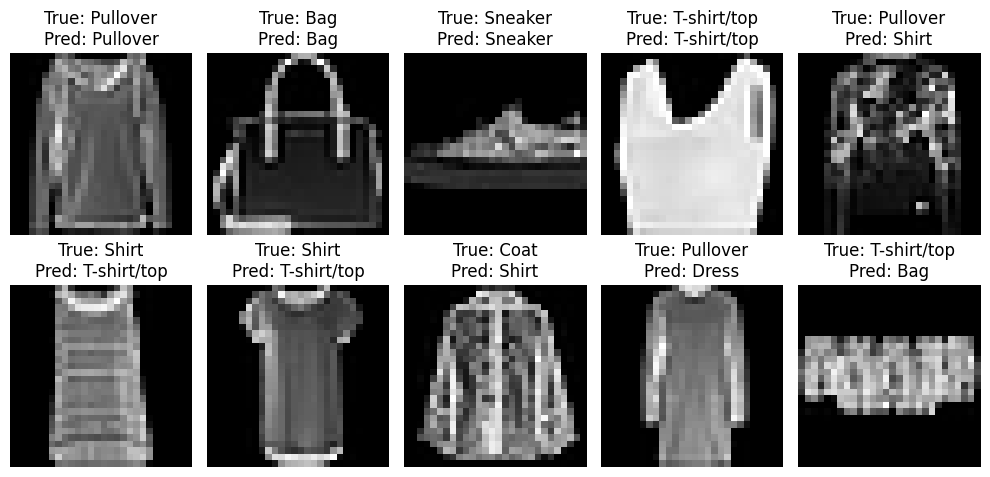

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# Select 5 random samples from the test set
# sample_indices = np.random.choice(len(x_test), 5, replace=False)
# sample_indices

# sample_indices = [5792, 9453, 3633, 3236, 9531] # with one error sample
# sample_indices = [2485, 6008, 1104, 3457, 2599]

def genearate_sample_images(model):
  sample_indices = [5792, 9453, 3633, 3236, 9531, 2485, 6008, 1104, 3457, 2599] # with one error sample
  sample_images = x_test[sample_indices]
  sample_labels = y_test[sample_indices]

  # Predict using the trained model
  predictions = model.predict(sample_images)

  # Map class indices to Fashion MNIST labels
  class_names = [
      'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
      'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
  ]

  # Plot the samples with predictions
  plt.figure(figsize=(10, 5))
  for i in range(10):
      plt.subplot(2, 5, i + 1)
      plt.imshow(sample_images[i], cmap='gray')
      predicted_label = np.argmax(predictions[i])
      true_label = sample_labels[i]
      plt.title(f"True: {class_names[true_label]}\nPred: {class_names[predicted_label]}")
      plt.axis('off')
  plt.tight_layout()
  plt.show()

  # sample_false_indices = [5792, 9453, 3633, 3236, 9531] # with one error sample
  # # sample_indices = [2485, 6008, 1104, 3457, 2599]
  # sample_images = x_test[sample_false_indices]
  # sample_labels = y_test[sample_false_indices]

  # # Predict using the trained model
  # predictions = model.predict(sample_images)

  # # Map class indices to Fashion MNIST labels
  # class_names = [
  #     'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
  #     'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
  # ]

  # # Plot the incorrect predictions
  # plt.figure(figsize=(10, 5))
  # for i in range(5):
  #     plt.subplot(1, 5, i + 1)
  #     plt.imshow(sample_images[i], cmap='gray')
  #     true_label = class_names[sample_labels[i]]
  #     pred_label = class_names[np.argmax(predictions[i])]
  #     plt.title(f"True: {true_label}\nPred: {pred_label}", color='red')
  #     plt.axis('off')
  # plt.tight_layout()
  # plt.show()

genearate_sample_images(model)

# With dropout

In [22]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# # Baseline CNN
# model = models.Sequential([
#     layers.Reshape((28, 28, 1), input_shape=(28, 28)),
#     layers.Conv2D(32, (3, 3), activation='relu'),
#     layers.MaxPooling2D((2, 2)),
#     layers.Conv2D(64, (3, 3), activation='relu'),
#     layers.MaxPooling2D((2, 2)),
#     layers.Flatten(),
#     layers.Dense(128, activation='relu'),
#     layers.Dense(10, activation='softmax')
# ])
# model.compile(optimizer='adam',
#               loss='sparse_categorical_crossentropy',
#               metrics=['accuracy'])

# # Baseline CNN + Dropout
# model = models.Sequential([
#     layers.Reshape((28, 28, 1), input_shape=(28, 28)),
#     layers.Conv2D(32, (3, 3), activation='relu'),
#     layers.MaxPooling2D((2, 2)),
#     layers.Dropout(0.25),
#     layers.Conv2D(64, (3, 3), activation='relu'),
#     layers.MaxPooling2D((2, 2)),
#     layers.Dropout(0.25),
#     layers.Flatten(),
#     layers.Dense(128, activation='relu'),
#     layers.Dropout(0.25),
#     layers.Dense(10, activation='softmax')
# ])
# model.compile(optimizer='adam',
#               loss='sparse_categorical_crossentropy',
#               metrics=['accuracy'])

# # Baseline CNN + Batch Normalization
# model = models.Sequential([
#     layers.Reshape((28, 28, 1), input_shape=(28, 28)),
#     layers.Conv2D(32, (3, 3), activation='relu'),
#     layers.BatchNormalization(),
#     layers.MaxPooling2D((2, 2)),
#     layers.Conv2D(64, (3, 3), activation='relu'),
#     layers.BatchNormalization(),
#     layers.MaxPooling2D((2, 2)),
#     layers.Flatten(),
#     layers.Dense(128, activation='relu'),
#     layers.BatchNormalization(),
#     layers.Dense(10, activation='softmax')
# ])
# model.compile(optimizer='adam',
#               loss='sparse_categorical_crossentropy',
#               metrics=['accuracy'])

# Deeper CNN
model = models.Sequential([
    layers.Reshape((28, 28, 1), input_shape=(28, 28)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train and evaluate
history = model.fit(x_train, y_train, epochs=10, validation_split=0.2)
# history = model.fit(x_train, y_train, epochs=50, validation_split=0.2, callbacks=[early_stopping])
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f"Training Accuracy: {history.history['accuracy'][-1]}")
print(f"Validation Accuracy: {history.history['val_accuracy'][-1]}")
print(f"Test Accuracy: {test_acc}")

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.7030 - loss: 0.7988 - val_accuracy: 0.8318 - val_loss: 0.4587
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8445 - loss: 0.4150 - val_accuracy: 0.8537 - val_loss: 0.3879
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8757 - loss: 0.3390 - val_accuracy: 0.8661 - val_loss: 0.3732
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8852 - loss: 0.3082 - val_accuracy: 0.8744 - val_loss: 0.3342
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8959 - loss: 0.2766 - val_accuracy: 0.8854 - val_loss: 0.3106
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9093 - loss: 0.2448 - val_accuracy: 0.8832 - val_loss: 0.3183
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9142 - loss: 0.2242 - val_accuracy: 0.8910 - val_loss: 0.3047
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.9248 - loss: 0.201

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 393ms/step


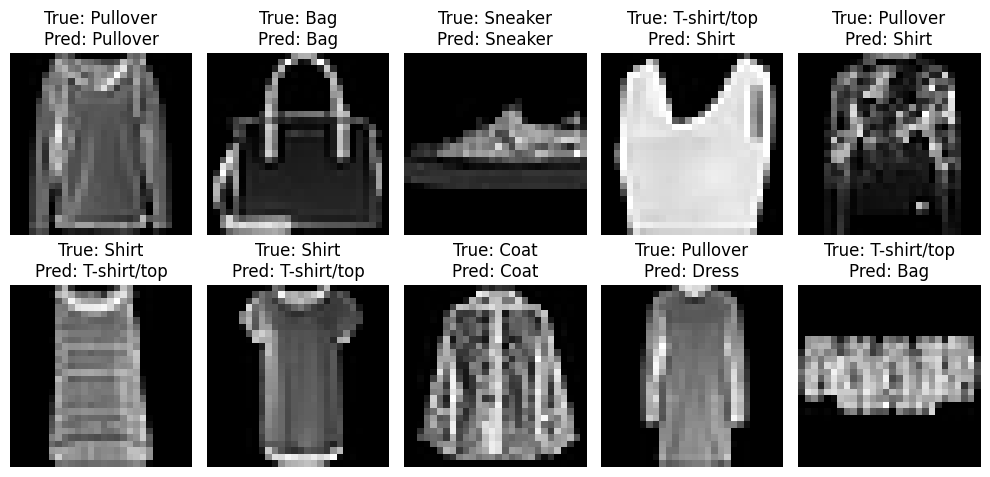

In [23]:
genearate_sample_images(model)